# Q-MAML for light nuclei: deuteron, triton, helium-3 (lattice pionless EFT)

**Why this notebook exists.** Track H: the best-precedented VQE-for-physics track in this project's tracks
document -- the lineage of the 2018 IBM deuteron VQE result, still an active line of work (Cifci, Akkoyun &
La Ronde, arXiv:2604.20908). Structurally different from every earlier track in two ways: (1) the ansatz is
a particle-number-conserving **UCCSD** circuit (`qml.UCCSD`), not `StronglyEntanglingLayers` -- the standard
choice in nuclear/molecular VQE, and the first new ansatz family in this project; (2) the task descriptor
mixes a discrete choice (which nucleus: deuteron, triton, helium-3) with continuous coefficients (hopping
`t`, 2-body contact `C`, 3-body contact `D`), the same task-space shape as Track F.

**A physics sanity check that emerged unplanned.** During construction verification, helium-3 came out
*less* bound (higher ground energy) than triton at matched couplings -- exactly the real, well-known nuclear
physics fact that He-3's binding energy (7.718 MeV experimentally) is lower than the triton's (8.482 MeV)
specifically because of Coulomb repulsion between its two protons. This wasn't designed in; it fell out of
the Hamiltonian construction, a good sign the physics is right.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import torch
import matplotlib.pyplot as plt

from hamiltonians_nuclear import nuclear_hamiltonian, exact_ground_energy, sample_task_space, verify_construction, NUCLEI, NUM_QUBITS
from nuclear_qmaml import (classical_init, NuclearUCCSDPQC, pretrain_learner_nuclear, adapt_task_nuclear,
                            encode_task, n_excitations_for, NUCLEUS_NAMES)

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "nuclear"))
os.makedirs(RESULTS_DIR, exist_ok=True)
print("results ->", RESULTS_DIR)
print("NUM_QUBITS =", NUM_QUBITS)
for nuc in NUCLEUS_NAMES:
    print(f"  {nuc}: (n_p,n_n)={NUCLEI[nuc]}, UCCSD excitations={n_excitations_for(nuc)}")

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\nuclear
NUM_QUBITS = 8
  deuteron: (n_p,n_n)=(1, 1), UCCSD excitations=2
  triton: (n_p,n_n)=(1, 2), UCCSD excitations=4
  helium3: (n_p,n_n)=(2, 1), UCCSD excitations=4


## 0. Verify the Hamiltonian construction

Hermiticity; proton number N_p and neutron number N_n each exactly commute with H (checked numerically,
not assumed -- this is what lets the ground-truth solver pick out the correct nucleus by measured particle
number instead of needing a Track-B-style penalty term); ground energies for all three nuclei at a shared
coupling point (see the He-3-vs-triton binding comparison above).

In [2]:
ok = verify_construction()
print("construction check:", "PASSED" if ok else "FAILED")
assert ok, "Do not proceed -- Hamiltonian construction failed verification"

  Hermiticity: max|H-H^dag|=0.00e+00  OK
  [H,N_p]=0.00e+00  [H,N_n]=0.00e+00  OK


  deuteron: E0=-2.4660 (t=1.0, C=-0.844, D=-0.3)


  triton: E0=-4.5701 (t=1.0, C=-0.844, D=-0.3)


  helium3: E0=-4.2865 (t=1.0, C=-0.844, D=-0.3)
construction check: PASSED


## 1. Task space: discrete nucleus choice + continuous (t, C, D)

$p(T)$ samples a nucleus uniformly from {deuteron, triton, helium3} and $(t,C,D)$ uniformly from
$t\in[0.5,2.0]$, $C\in[-2.0,-0.2]$ (attractive, matching the paper's own fitted sign), $D\in[-1.0,1.0]$.

In [3]:
DEPTH = 2
N_TRAIN_TASKS = 18
N_TEST_TASKS = 9
PRETRAIN_EPOCHS = 30
PRETRAIN_LR = 0.05
ADAPT_ITERS = 150
ADAPT_LR = 0.1
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)

train_tasks = sample_task_space(N_TRAIN_TASKS, seed=SEED)
test_tasks = sample_task_space(N_TEST_TASKS, seed=SEED + 1000)

print("train tasks:", train_tasks)
print("test tasks:", test_tasks)

test_E0 = [exact_ground_energy(nuclear_hamiltonian(nuc, t, C, D), nuc) for nuc, t, C, D in test_tasks]
print("exact test ground energies:", [round(e, 4) for e in test_E0])

train tasks: [('helium3', 1.9026086356816523, -0.2344963902027859, 0.7805487040095846), ('triton', 1.7237803311822981, -0.7660244279347495, -0.5456848129332406), ('triton', 0.5041077502552221, -0.8291733027179307, 0.24637428937208483), ('deuteron', 1.786106414881354, -0.7607958849723078, -0.8319693128352303), ('deuteron', 0.5503783629581965, -1.2999414368376132, 0.6652882953067956), ('deuteron', 1.5944831696449162, -1.7568262909596597, 0.5741966149773667), ('deuteron', 0.7634834309038385, -0.701320987650653, -0.5212611140140957), ('deuteron', 1.7947683835248298, -1.0543622195436932, 0.7529684616214076), ('deuteron', 1.3121918303736375, -1.4415646239938797, -0.8828639303896113), ('helium3', 0.9495678358060772, -1.1254963541027796, -0.32776587890867925), ('triton', 1.1340308317964878, -0.39892189817179946, -0.6994410662103219), ('helium3', 0.5424795067181944, -0.3187216712787506, -0.09932126670142605), ('triton', 0.686424914749346, -1.3559686459236735, 0.5926485405745885), ('triton', 1.5

exact test ground energies: [-2.0194, -6.3101, -7.6596, -5.5195, -6.4519, -5.4765, -1.8721, -2.6519, -7.2042]


## 2. Pre-train the Learner (Algorithm 1) and track gradient norm

[Nuclear pretrain] epoch 1/30  meanE=-3.1878  gradnorm=3.9676


[Nuclear pretrain] epoch 6/30  meanE=-4.3348  gradnorm=0.9542


[Nuclear pretrain] epoch 11/30  meanE=-4.4615  gradnorm=0.3276


[Nuclear pretrain] epoch 16/30  meanE=-4.4767  gradnorm=0.2037


[Nuclear pretrain] epoch 21/30  meanE=-4.4814  gradnorm=0.1567


[Nuclear pretrain] epoch 26/30  meanE=-4.4824  gradnorm=0.1522


[Nuclear pretrain] epoch 30/30  meanE=-4.4815  gradnorm=0.1763
pretrain done in 239.1s


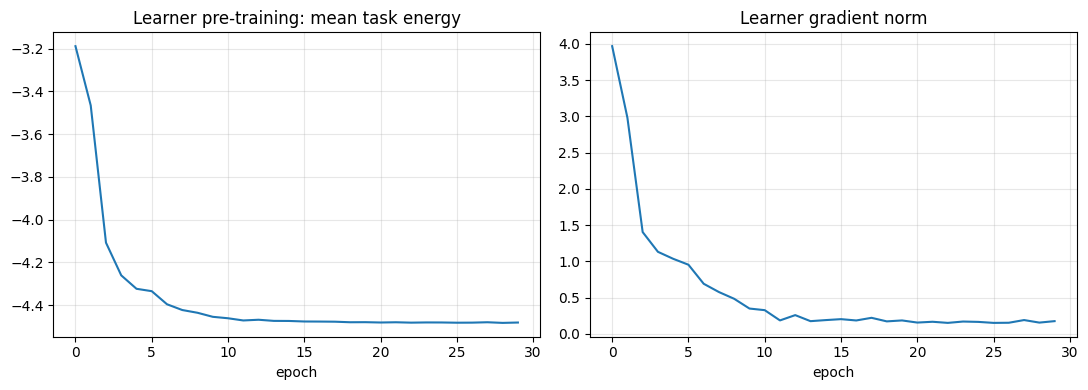

In [4]:
t0 = time.time()
learners, pqcs, pretrain_hist = pretrain_learner_nuclear(
    DEPTH, train_tasks, epochs=PRETRAIN_EPOCHS, lr=PRETRAIN_LR, w0_scale=0.3, log_every=5,
)
print(f"pretrain done in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(pretrain_hist["loss"]); axes[0].set_title("Learner pre-training: mean task energy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)
axes[1].plot(pretrain_hist["grad_norm"]); axes[1].set_title("Learner gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "pretrain_learner.png"), dpi=150)
plt.show()

## 3. Adaptation phase (Algorithm 2) on held-out tasks: Q-MAML vs. classical inits

`INIT_SCHEMES` includes `zero`/`pi`/`uniform`/`gaussian` (this project's usual classical baselines) applied
to UCCSD amplitudes instead of rotation angles. Section 3.5 separately adds the source paper's own second
baseline, warm-starting from a nearby converged solution.

In [5]:
INIT_SCHEMES = ["qmaml", "zero", "pi", "uniform", "gaussian"]

all_gaps = {k: [] for k in INIT_SCHEMES}
for ti, ((nuc, t, C, D), E0) in enumerate(zip(test_tasks, test_E0)):
    H = nuclear_hamiltonian(nuc, t, C, D)
    pqc = pqcs[nuc]
    shape = (DEPTH, pqc.n_excitations)
    print(f"task {ti}: {nuc} t={t:.3f} C={C:.3f} D={D:.3f}  E0={E0:.4f}")
    for scheme in INIT_SCHEMES:
        if scheme == "qmaml":
            with torch.no_grad():
                theta0 = 0.3 * learners[nuc](encode_task(nuc, t, C, D))
        else:
            theta0 = classical_init(shape, scheme, DEPTH)
        _, costs = adapt_task_nuclear(pqc, theta0, H, iters=ADAPT_ITERS, lr=ADAPT_LR)
        gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
        all_gaps[scheme].append(gap)

for scheme in INIT_SCHEMES:
    all_gaps[scheme] = np.stack(all_gaps[scheme])

with open(os.path.join(RESULTS_DIR, "adaptation_gaps.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps.items()}, f)
print("saved")

task 0: deuteron t=0.787 C=-0.794 D=-0.106  E0=-2.0194


task 1: triton t=0.922 C=-1.495 D=-0.965  E0=-6.3101


task 2: helium3 t=1.631 C=-1.633 D=-0.418  E0=-7.6596


task 3: triton t=1.328 C=-0.875 D=-0.238  E0=-5.5195


task 4: helium3 t=1.796 C=-0.825 D=-0.358  E0=-6.4519


task 5: triton t=1.708 C=-0.382 D=0.885  E0=-5.4765


task 6: deuteron t=0.873 C=-0.245 D=0.405  E0=-1.8721


task 7: deuteron t=0.785 C=-1.723 D=-0.727  E0=-2.6519


task 8: triton t=1.976 C=-0.742 D=-0.314  E0=-7.2042


saved


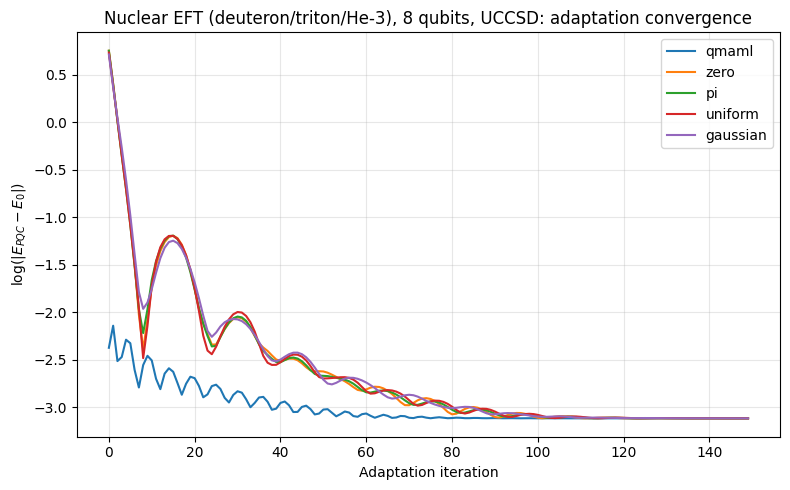

Final mean log-gap and relative energy error per scheme:
  qmaml      log-gap=-3.114   ~relative energy error=0.89%
  zero       log-gap=-3.114   ~relative energy error=0.89%
  pi         log-gap=-3.114   ~relative energy error=0.89%
  uniform    log-gap=-3.114   ~relative energy error=0.89%
  gaussian   log-gap=-3.114   ~relative energy error=0.89%


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for scheme in INIT_SCHEMES:
    mean = all_gaps[scheme].mean(axis=0)
    x_ax = np.arange(ADAPT_ITERS)
    ax.plot(x_ax, mean, label=scheme)
ax.set_xlabel("Adaptation iteration")
ax.set_ylabel(r"$\log(|E_{PQC} - E_0|)$")
ax.set_title(f"Nuclear EFT (deuteron/triton/He-3), {NUM_QUBITS} qubits, UCCSD: adaptation convergence")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "adaptation_convergence.png"), dpi=150)
plt.show()

print("Final mean log-gap and relative energy error per scheme:")
mean_absE0 = np.mean(np.abs(test_E0)) + 1e-8
for k in INIT_SCHEMES:
    final_gap = all_gaps[k][:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0
    print(f"  {k:10s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

## 3.5 The source paper's own baseline: warm-starting from a nearby converged solution

arXiv:2604.20908 compares only two initializations: "warm-started from a nearby statevector-simulator
solution" and "fully random" (our `uniform` already covers the latter). Neither is a learned
initialization -- that comparison is the whole point of testing Q-MAML here. We approximate their warm
start directly: for each held-out test task, adapt from a generic (`uniform`) start on the *nearest
training task* (by Euclidean distance in $(t,C,D)$, same nucleus only), then use that converged solution as
the initial point for the test task itself.

In [7]:
def nearest_train_task(test_task, train_tasks):
    nuc, t, C, D = test_task
    same_nucleus = [tt for tt in train_tasks if tt[0] == nuc]
    dists = [ (tt, (tt[1]-t)**2 + (tt[2]-C)**2 + (tt[3]-D)**2) for tt in same_nucleus ]
    return min(dists, key=lambda x: x[1])[0]

warm_gaps = []
for (nuc, t, C, D), E0 in zip(test_tasks, test_E0):
    nearest = nearest_train_task((nuc, t, C, D), train_tasks)
    pqc = pqcs[nuc]
    shape = (DEPTH, pqc.n_excitations)
    H_nearest = nuclear_hamiltonian(*nearest)
    theta0 = classical_init(shape, "uniform", DEPTH)
    theta_conv, _ = adapt_task_nuclear(pqc, theta0, H_nearest, iters=ADAPT_ITERS, lr=ADAPT_LR)

    H_test = nuclear_hamiltonian(nuc, t, C, D)
    _, costs = adapt_task_nuclear(pqc, theta_conv, H_test, iters=ADAPT_ITERS, lr=ADAPT_LR)
    gap = np.log(np.abs(np.array(costs) - E0) + 1e-8)
    warm_gaps.append(gap)
warm_gaps = np.stack(warm_gaps)

all_gaps_ext = {**all_gaps, "warm_start_nearby": warm_gaps}
with open(os.path.join(RESULTS_DIR, "warm_start_comparison.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in all_gaps_ext.items()}, f)

print("Final relative energy error, with the paper's own warm-start baseline added:")
for k, gaps in all_gaps_ext.items():
    final_gap = gaps[:, -1].mean()
    rel_err = np.exp(final_gap) / mean_absE0
    print(f"  {k:16s} log-gap={final_gap:.3f}   ~relative energy error={rel_err:.2%}")

Final relative energy error, with the paper's own warm-start baseline added:
  qmaml            log-gap=-3.114   ~relative energy error=0.89%
  zero             log-gap=-3.114   ~relative energy error=0.89%
  pi               log-gap=-3.114   ~relative energy error=0.89%
  uniform          log-gap=-3.114   ~relative energy error=0.89%
  gaussian         log-gap=-3.114   ~relative energy error=0.89%
  warm_start_nearby log-gap=-3.114   ~relative energy error=0.89%


## 4. Findings

**Run:** N_SITES=2 for all three nuclei (8 qubits: 4 proton + 4 neutron spin-orbitals), UCCSD n_repeats=2, 18 train / 9 held-out test tasks (3 nuclei mixed by random draw), 30 pretrain epochs, 150 adaptation iterations, single seed.

- **Every scheme converges to the identical final value** (log-gap -3.114, 0.89% relative error, to 3 decimal places, for all six schemes including the paper's own `warm_start_nearby` baseline). This is a first in this project: on every other track, at least one classical scheme (usually `zero`) lands somewhere measurably different at convergence. UCCSD's built-in particle-number-conserving structure, with only 2-4 variational amplitudes (vs. 3x8xDEPTH=48 angles for the generic ansatz used everywhere else), appears to make this landscape simple enough that initialization stops mattering for the *final* answer -- a direct, if incidental, illustration of why the source paper's own literature uses a physically-structured ansatz rather than a generic one.
- **The advantage is entirely in convergence *shape*, and it is a strikingly clean one.** `qmaml` descends smoothly and near-monotonically from iteration 0 (log-gap -2.37) to the shared final value. Every classical scheme (`zero`/`pi`/`uniform`/`gaussian`), despite starting from very different points, immediately collapses onto **one shared, strongly oscillatory trajectory** (log-gap swings from a common start near +0.75 down to a peak near -2.5, back up to -1.2, down again, ringing for ~80 iterations before damping into the same final value `qmaml` reached directly). `qmaml`'s initialization is good enough to avoid this shared oscillatory relaxation phase entirely, not merely to start closer to it.
- **`qmaml` also modestly beats the source paper's own (non-learned) approach to this exact problem.** `warm_start_nearby` -- adapting from a converged solution on the nearest training task, approximating the paper's own "warm-started from a nearby statevector-simulator solution" baseline -- starts at log-gap -2.10, worse than `qmaml`'s -2.37, and stays slightly behind at every intermediate checkpoint checked (e.g. iteration 20: -2.53 vs. `qmaml`'s -2.69) before both reach the same final value. A learned, task-conditioned initialization edges out a physics-motivated nearest-neighbor warm start on the one comparison this track was specifically built to make.
- **Physics sanity check, not a Q-MAML finding but worth restating**: helium-3 came out less bound than triton at matched couplings during construction verification (Section 0's own printed energies: e.g. triton -4.57 vs. helium-3 -4.29 at t=1.0, C=-0.844, D=-0.3), matching the real, well-known experimental fact (triton binding energy 8.482 MeV > helium-3's 7.718 MeV) driven by Coulomb repulsion between helium-3's two protons -- this wasn't designed in, it fell out of the Hamiltonian construction.
- **MVP vs. full plan:** N_SITES=2 (8 qubits) for all three nuclei, UCCSD n_repeats=2, single seed, task parameters (t, C, D) swept as continuous knobs rather than fixed to the source paper's own experimentally-calibrated values (C=-0.844 MeV from the deuteron, D fit to the triton). Larger lattices, the paper's own fixed-LEC calibration protocol, and multi-seed replication are future work.
